In [1]:
import sqlite3
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

connection_ = create_engine("sqlite:///histories.db")

In [2]:
in_game_ts_df = pd.read_sql_table('in_game_ts', con=connection_)
player_statistic_df = pd.read_sql_table('player_statistic', con=connection_)
point_usage_df = pd.read_sql_table('point_usage_statistic', con=connection_)
species_defeated_df = pd.read_sql_table('species_defeated', con=connection_)

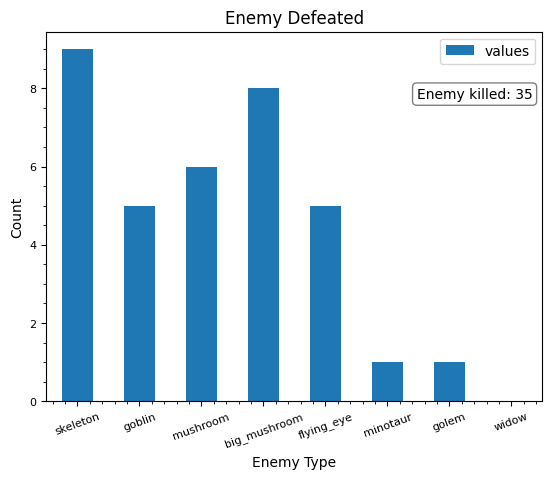

In [3]:
this_lab = []
values_ = []
for i in species_defeated_df:
    if i in ['id']:
        continue
    this_lab.append(i)
    values_.append(species_defeated_df[i].sum())
tmp_df = pd.DataFrame({'Enemy type': this_lab, 'values': values_})
ax = tmp_df.plot.bar(x="Enemy type", y="values", rot=0, title='Enemy Defeated', fontsize=8)
ax.set_xlabel('Enemy Type', fontsize=10)
ax.set_ylabel('Count', fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20)
ax.minorticks_on()

ax.text(0.98, 0.85, f'Enemy killed: {sum(values_)}', transform=ax.transAxes, ha='right', va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
plt.savefig('./plots/barplot.png', dpi=300)

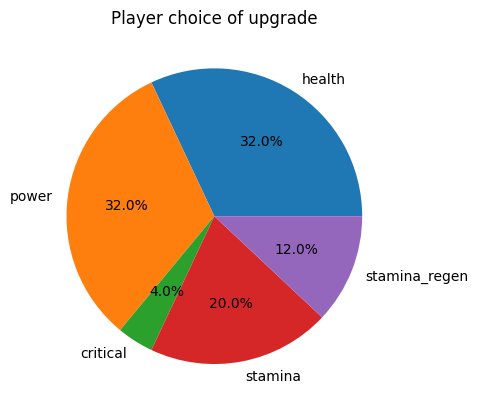

In [4]:
this_lab = []
values_ = []
for i in point_usage_df:
    if i == 'id':
        continue
    this_lab.append(i)
    values_.append(point_usage_df[i].sum())
tmp_df = pd.DataFrame({'Skills': this_lab, 'values': values_})
plt.pie(values_, labels=this_lab, autopct='%1.1f%%')
plt.title('Player choice of upgrade')
# plt.show()
plt.savefig('./plots/pieplot.png', dpi=300)

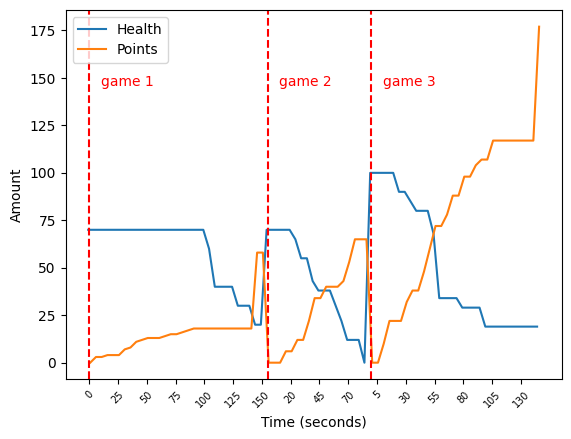

In [5]:
x = np.arange(len(in_game_ts_df))
width = 0.35

plt.plot(x - width/2, in_game_ts_df['health'], label='Health')
plt.plot(x + width/2, in_game_ts_df['points'], label='Points')

# in_game_ts_df

plt.xticks(x[::5], in_game_ts_df['time_stamp'][::5])

plt.xticks(fontsize=7, rotation=45)
plt.xlabel('Time (seconds)')
plt.ylabel('Amount')

zero_points = in_game_ts_df[in_game_ts_df['time_stamp'] == 0]
# print(zero_points)

game = 1
for ts in zero_points['id']-1:
    # print(ts)
    plt.axvline(x=ts, color='red', linestyle='--')
    plt.text(ts+2, plt.ylim()[1]-40, f'game {game}', color='red', fontsize=10)
    game+=1
game = 0

plt.legend()
# plt.show()
plt.savefig('./plots/lineplot.png', dpi=300)

In [ ]:
# fig, ax = plt.subplots(figsize=(10, len(in_game_ts_df) * 0.3))
# ax.axis('off')

# table = ax.table(
#     cellText=in_game_ts_df.values,
#     colLabels=in_game_ts_df.columns,
#     loc='center'
# )
# table.auto_set_font_size(False)
# table.set_fontsize(8)
# table.auto_set_column_width(col=list(range(len(in_game_ts_df.columns))))

# # add stats at bottom
# stats = in_game_ts_df.agg(['mean', 'std', 'median']).round(2)
# for i, (idx, row) in enumerate(stats.iterrows()):
#     for j, val in enumerate(row):
#         table[len(in_game_ts_df)+1+i, j].get_text().set_text(f'{idx}: {val}')

# # plt.show()
# plt.savefig('plot.png', dpi=300)